# S&P 500 multivariate forecasting — smoke-test notebook

Faster sibling of `sp500_multivariate_backtest_demo.ipynb`: same structure and
same `DataService`, but **YAML-driven settings** in
``sp500_multivariate_backtest_smoke.yaml`` are tuned so a full Run All
finishes in **under one minute** on a laptop (cached parquet + a handful of
forecast origins + fast models only). Use the main notebook + full YAML for the
actual backtests and slides.

**What you get in this notebook**

1. A compact **observed-history** figure for the target log return (context for the score).
2. A plain-text **`describe_spec()`** summary of the active `BacktestSpec` (the
   Canada food CPI notebook prints YAML-backed specs the same way).
3. A unified **`RESULTS_DF`** leaderboard: mean CRPS in **log-return** space and
   mean CRPS on **realised same-day open (USD)** (pushing each log-return quantile
   through `prior_adj_close * exp(q)`), plus covariate usage and **direction**
   metrics (point sign vs realised sign; ROC on `prob_up` from quantiles).
4. A **formatted table** plus **mean CRPS bar charts** (log return and open level)
   for slides.
5. An **open-price** line chart (actual vs median-implied open, with a 5–95% band)
   for one illustrative model on the scored backtest dates.

---

**How to run:** edit **`sp500_multivariate_backtest_smoke.yaml`**, then **Run All**.  The
multivariate README documents prerequisites and the no-leakage contract.


---
## 1. Setup

Heavy lifting lives in Python modules next to this notebook:

- `sp500_multivariate_backtest_smoke.yaml` — backtest task/window, model toggles, lags, covariates.
- `multivariate_backtest_grid.py` — grid of `backtest` runs, open-level CRPS, direction metrics.
- `data.py` — `build_sp500_multivariate_service()`, covariate series ids, lagging policy.
- `plots.py` — matplotlib figures (target history, CRPS bars).
- `analysis.py` — `style_results_dataframe()` for readable leaderboards.

Predictors are imported from `aieng.forecasting.methods` (re-exports
`DartsLinearRegressionPredictor`, `DartsLightGBMPredictor`, and
`DartsAutoARIMAPredictor`).

**Prereq:** run `uv sync` once from the repo root and select the project's
`.venv` kernel. uv's editable install exposes `aieng.forecasting` and the
top-level `experiments` namespace, but **not** the `implementations` package
— the helpers in `data.py` / `plots.py` import via `implementations.experiments.*`,
so the imports cell below prepends the repo root onto `sys.path` first.



In [10]:
from __future__ import annotations

import sys
from pathlib import Path

# Walk up from cwd to the repo root (the dir containing both workspace members),
# then prepend the workspace member dirs onto ``sys.path``. The editable installs
# uv writes for ``aieng-forecasting`` / ``implementations`` are skipped by Python
# on macOS iCloud Drive ("Mobile Documents") checkouts, so this bootstrap is the
# reliable way in.
REPO_ROOT = next(
    p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir()
)
for sub in (REPO_ROOT, REPO_ROOT / "aieng-forecasting", REPO_ROOT / "implementations"):
    if str(sub) not in sys.path:
        sys.path.insert(0, str(sub))
REPO_ROOT


PosixPath('/Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting')

---
## 2. Configuration (YAML + loader cell)

All experiment parameters live in **`sp500_multivariate_backtest_smoke.yaml`**
(next to this notebook): `backtest` (task + evaluation window + warmup) and
`experiment` (data cache window, which models to run, lags, covariate subset,
LightGBM thread kwargs). The next code cell loads that file into the same Python
names the rest of the notebook already uses (`RUN_MODELS`, `SPEC_*`,
`DATA_HISTORY_START`, …).

`backtest.start` / `backtest.end` are **forecast origins** (`as_of`): one full
backtest fit per business day in that inclusive range. For `horizons: [1]` and
`frequency: B`, each scored prediction’s `forecast_date` is the **next** business
session after `as_of` (see `describe_spec` output).

`experiment.data_history_start` should be **well before** your first origin so
lag features and covariates look like production. `backtest.warmup` is the
minimum **rows of target** required at each origin; use at least ~one trading
year (~252) for a realistic floor in heavier runs, not just the lag length.



In [11]:
# =============================================================================
# Experiment config — loaded from YAML next to this notebook.
# Edit ``sp500_multivariate_backtest_smoke.yaml`` (backtest window, models,
# lags, covariates, data cache flags). Use ``sp500_multivariate_backtest_demo.ipynb``
# and ``sp500_multivariate_backtest_full.yaml`` for the full experiment.
# =============================================================================

from pathlib import Path

import yaml

_repo_root = next(
    p
    for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir()
)
EXPERIMENT_CONFIG_PATH = (
    _repo_root
    / "implementations/experiments/stock_price_forecasting_multivariate/sp500_multivariate_backtest_smoke.yaml"
)

with open(EXPERIMENT_CONFIG_PATH, encoding="utf-8") as f:
    EXPERIMENT_CFG = yaml.safe_load(f)

_bt = EXPERIMENT_CFG["backtest"]
_ex = EXPERIMENT_CFG["experiment"]

RUN_MODELS = dict(_ex["run_models"])
SPEC_START = _bt["start"]
SPEC_END = _bt["end"]
SPEC_STRIDE = int(_bt["stride"])
SPEC_WARMUP = int(_bt["warmup"])
DATA_HISTORY_START = _ex["data_history_start"]
REFRESH_CACHE = bool(_ex["refresh_cache"])
LAGS = int(_ex["lags"])
LAGS_PAST_COVARIATES = int(_ex["lags_past_covariates"])
NUM_SAMPLES = int(_ex["num_samples"])
FAST_COVARIATE_SERIES_IDS = list(_ex["fast_covariate_series_ids"])
LIGHTGBM_KWARGS = dict(_ex["lightgbm_kwargs"])

print(f"Loaded experiment config: {EXPERIMENT_CONFIG_PATH}")


Loaded experiment config: /Users/behnoosh/Library/Mobile Documents/com~apple~CloudDocs/aieng/agentic-forecasting/implementations/experiments/stock_price_forecasting_multivariate/sp500_multivariate_backtest_smoke.yaml


---
## 3. Imports



In [12]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

# Defensive sys.path bootstrap so this cell works even if the dedicated
# bootstrap cell above wasn't executed first. The uv editable install exposes
# ``aieng.forecasting`` and the ``experiments`` / ``methods`` namespaces, but
# **not** the ``implementations`` package — the modules below need the repo
# root on ``sys.path`` to resolve ``implementations.experiments.*``.
_repo_root = next(
    p
    for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "aieng-forecasting").is_dir() and (p / "implementations").is_dir()
)
for _sub in (_repo_root, _repo_root / "aieng-forecasting", _repo_root / "implementations"):
    if str(_sub) not in sys.path:
        sys.path.insert(0, str(_sub))

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

from aieng.forecasting.evaluation import (
    BacktestSpec,
    describe_spec,
)
from implementations.experiments.stock_price_forecasting_multivariate import (
    DEFAULT_COVARIATE_SERIES_IDS,
    SP500_LOG_RETURN_SERIES_ID,
    SP500_TICKER,
    build_sp500_multivariate_service,
)
from implementations.experiments.stock_price_forecasting_single_variable.data import (
    DEFAULT_CACHE_FILE,
    YahooFinanceDailyAdapter,
)
from implementations.experiments.stock_price_forecasting_multivariate.plots import (
    display_multivariate_backtest_leaderboard,
    plot_open_forecast_vs_actual,
    plot_sp500_log_return_recent,
)
from implementations.experiments.stock_price_forecasting_multivariate.multivariate_backtest_grid import (
    build_open_price_compare_frame,
    run_backtest_for_run_key,
    run_multivariate_backtest_grid,
)


---
## 4. Build data services

- **`svc_no_cov`** — target only (baseline).
- **`svc_cov`** — target plus every covariate that successfully registered
  (missing optional feeds are skipped with warnings unless you enable strict mode
  in `data.py`).



In [13]:
svc_no_cov = build_sp500_multivariate_service(
    include_covariates=False,
    start=DATA_HISTORY_START,
    end=None,
    refresh=REFRESH_CACHE,
)

svc_cov = build_sp500_multivariate_service(
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    end=None,
    refresh=REFRESH_CACHE,
)

registered_covariates = [
    sid for sid in DEFAULT_COVARIATE_SERIES_IDS if sid in set(svc_cov.series_ids)
]
selected_covariates = [sid for sid in FAST_COVARIATE_SERIES_IDS if sid in registered_covariates]
if not selected_covariates:
    selected_covariates = registered_covariates

print("svc_no_cov:", svc_no_cov.series_ids)
print("svc_cov count:", len(svc_cov.series_ids))
print("selected covariates:", selected_covariates)

# Same Yahoo cache window as ``build_sp500_multivariate_service`` (for open-level CRPS).
_sp500_price_adapter = YahooFinanceDailyAdapter(
    SP500_TICKER,
    start=DATA_HISTORY_START,
    end=None,
    cache_path=DEFAULT_CACHE_FILE,
    refresh=REFRESH_CACHE,
)
SP500_PRICE_DF = _sp500_price_adapter.fetch()



svc_no_cov: ['sp500_log_ret_1b']
svc_cov count: 11
selected covariates: ['vix_level_l1b', 'vix_log_ret_1b_l1b', 'ust10y_level_l1b', 'ust2y10y_spread_l1b', 'cpi_mom_logdiff_l1b', 'unemployment_rate_l1b', 'oil_log_ret_1b_l1b', 'dollar_index_log_ret_1b_l1b', 'nasdaq_log_ret_1b_l1b']


---
## 5. Target context — observed log returns

One panel of recent **realised** prior-close-to-next-open log returns (the same
series the models forecast).



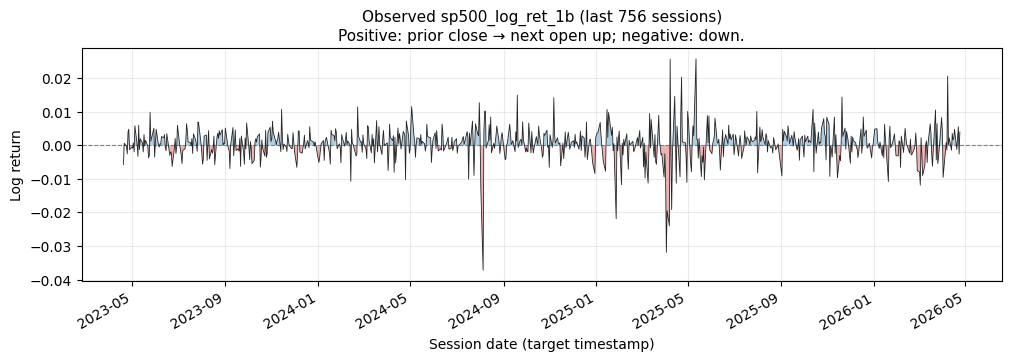

In [14]:
fig, _ = plot_sp500_log_return_recent(svc_no_cov, n_trading_days=756)
plt.show()



---
## 6. Task and backtest window

The evaluation window comes from the YAML **`backtest`** block (loaded into
`spec` below). Printing `describe_spec` keeps the notebook self-documenting
(same spirit as the Canada food CPI experiment).



In [20]:
spec = BacktestSpec.model_validate(EXPERIMENT_CFG["backtest"])

# print(describe_spec(spec, data_service=svc_cov))




---
## 7. Backtests — one row per enabled model (`multivariate_backtest_grid.py`)

Each `true` entry under ``experiment.run_models`` in the YAML (loaded as
``RUN_MODELS``) runs a full `backtest` (one fit per origin).
`mean_crps` is CRPS on the **log-return** target; `mean_crps_open` is CRPS on the
**realised open price (USD)** using the same quantile fan mapped through
`prior_adj_close * exp(q)`.

The table below is sorted by **mean CRPS (log)** (lower is better).



In [16]:
RESULTS_DF = run_multivariate_backtest_grid(
    run_models=RUN_MODELS,
    spec=spec,
    selected_covariates=selected_covariates,
    svc_no_cov=svc_no_cov,
    svc_cov=svc_cov,
    price_df=SP500_PRICE_DF,
    lags=LAGS,
    lags_past_covariates=LAGS_PAST_COVARIATES,
    num_samples=NUM_SAMPLES,
    lightgbm_kwargs=LIGHTGBM_KWARGS,
)


---
## 8. Open price — point forecast vs realised

One **illustrative** run: the code tries, in order, ``linreg_with_covariates``,
``lightgbm_with_covariates``, then univariate runs (``linreg_target_only``, …)
among **enabled** YAML entries. Some macro covariates are not strictly on a
business-day (``B``) calendar; Darts then raises when building past covariates,
so the cell **falls back** to the next candidate instead of failing.

The curve maps the **median** log-return forecast to USD with
``prior_adj_close * exp(q)`` (same scaling as open-level CRPS). The shaded band
pushes the **5th and 95th** log-return quantiles through the same mapping.


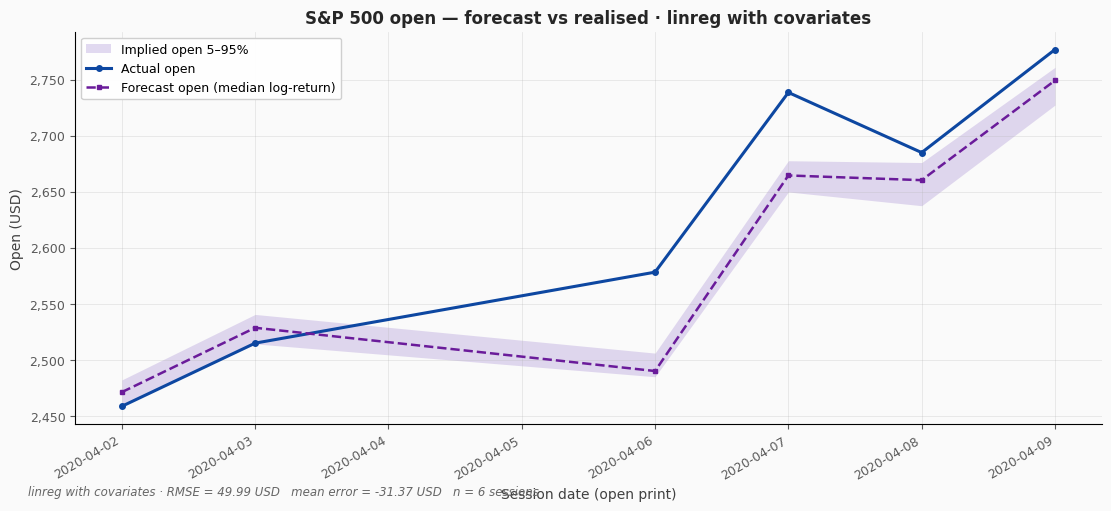

In [17]:
_open_demo_plan: list[str] = []
if RUN_MODELS.get("linreg_with_covariates"):
    _open_demo_plan.append("linreg_with_covariates")
if RUN_MODELS.get("lightgbm_with_covariates"):
    _open_demo_plan.append("lightgbm_with_covariates")
if RUN_MODELS.get("linreg_target_only"):
    _open_demo_plan.append("linreg_target_only")
if RUN_MODELS.get("lightgbm_target_only"):
    _open_demo_plan.append("lightgbm_target_only")
if RUN_MODELS.get("autoarima_target_only"):
    _open_demo_plan.append("autoarima_target_only")
_seen: set[str] = set()
_open_demo_plan = [k for k in _open_demo_plan if not (k in _seen or _seen.add(k))]

_open_bt = None
_open_demo_key: str | None = None
_open_fail_msgs: list[str] = []
for _k in _open_demo_plan:
    try:
        _open_bt = run_backtest_for_run_key(
            run_key=_k,
            spec=spec,
            selected_covariates=selected_covariates,
            svc_no_cov=svc_no_cov,
            svc_cov=svc_cov,
            lags=LAGS,
            lags_past_covariates=LAGS_PAST_COVARIATES,
            num_samples=NUM_SAMPLES,
            lightgbm_kwargs=LIGHTGBM_KWARGS,
        )
        _open_demo_key = _k
        break
    except ValueError as _exc:
        _open_fail_msgs.append(f"{_k}: {_exc}")
        continue

if _open_bt is not None and _open_demo_key is not None:
    if _open_fail_msgs:
        print(
            "Open-price illustration: skipped some runs (macro covariates are not always "
            "strictly business-day aligned for Darts); using "
            f"{_open_demo_key!r}. Details:\n" + "\n".join(_open_fail_msgs)
        )
    _open_df = build_open_price_compare_frame(_open_bt.predictions, SP500_PRICE_DF)
    _title = "S&P 500 open — forecast vs realised · " + _open_demo_key.replace("_", " ")
    fig, _ = plot_open_forecast_vs_actual(
        _open_df,
        title=_title,
        run_label=_open_demo_key.replace("_", " "),
    )
    plt.show()
else:
    print("No enabled model completed — skip open-price illustration.")
    if _open_fail_msgs:
        print("\n".join(_open_fail_msgs))


---
## 9. Leaderboard — formatted table and CRPS charts (log vs open)


,run_key,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,mean_crps_open,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,error
4,autoarima_target_only,autoarima target only,False,0,—,darts_autoarima,0.01266,33.068,6,6,0,0.500,0.500,0.500,0.333,0.250,6,
2,lightgbm_target_only,lightgbm target only,False,0,—,darts_lightgbm,0.01291,33.799,6,6,0,0.750,0.750,0.750,0.667,0.500,6,
3,lightgbm_with_covariates,lightgbm with covariates,True,9,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.01317,34.343,6,6,0,0.600,0.750,0.667,0.500,0.250,6,
0,linreg_target_only,linreg target only,False,0,—,darts_linreg,0.01339,35.053,6,6,0,0.800,1.000,0.889,0.833,0.750,6,
1,linreg_with_covariates,linreg with covariates,True,9,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,0.01360,35.644,6,6,0,0.800,1.000,0.889,0.833,0.500,6,


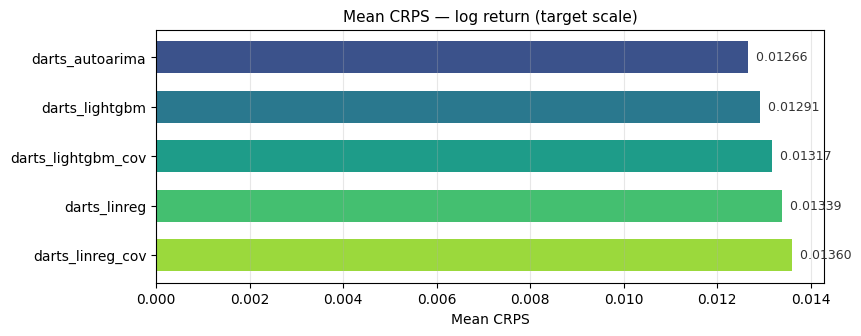

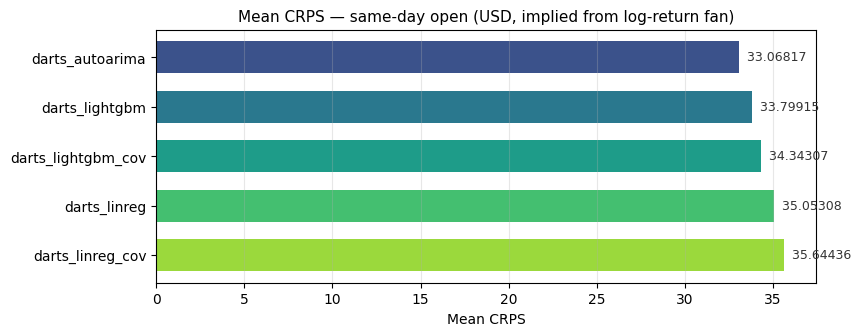

In [18]:
display_multivariate_backtest_leaderboard(RESULTS_DF)
